In [1]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
clf = IsolationForest(contamination='auto')
clf.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [7]:
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
print(y_pred_train)
print(y_pred_test)

[ 1  1  1  1 -1  1 -1  1  1 -1  1  1  1 -1 -1  1 -1  1  1  1  1  1 -1  1
  1  1 -1  1  1 -1  1 -1  1 -1 -1  1  1  1  1  1  1 -1  1 -1  1 -1  1  1
  1 -1  1 -1 -1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1  1 -1  1  1 -1 -1  1 -1  1  1  1 -1  1  1  1  1
  1  1  1  1  1 -1 -1  1  1]
[ 1 -1 -1  1  1  1  1  1 -1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1 -1 -1  1  1  1  1  1  1  1 -1  1  1  1 -1  1]


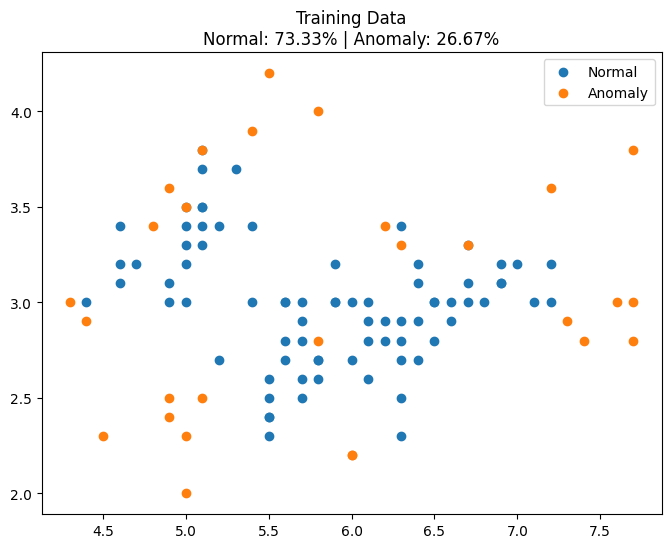

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def create_scatter_plot(X, y, title):
    plt.figure(figsize=(8, 6))

    # Scatter plot
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Normal')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Anomaly')

    # Calculate percentages
    total = len(y)
    normal_pct = np.sum(y == 1) / total * 100
    anomaly_pct = np.sum(y == -1) / total * 100

    # Title with percentage
    plt.title(f"{title}\nNormal: {normal_pct:.2f}% | Anomaly: {anomaly_pct:.2f}%")

    plt.legend()
    plt.show()


# Call function
create_scatter_plot(X_train, y_pred_train, 'Training Data')